In [ ]:
from sklearn.preprocessing import StandardScaler

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
from data_load import dataset

In [10]:
dataset.head(10)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5
5,20210101,5,89,83,99,98,92,0,-5.5,2.1,66,0.0,109.8,5,1,1,0.0,1.5
6,20210101,6,102,111,110,103,107,0,-5.6,1.5,67,0.0,109.8,5,1,1,0.0,1.5
7,20210101,7,92,75,48,29,61,0,-6.8,0.6,73,0.0,109.8,5,1,1,0.0,1.5
8,20210101,8,27,25,22,22,24,0,-5.6,0.0,72,0.0,109.8,5,1,1,0.0,1.5
9,20210101,9,22,22,22,22,22,0,-3.3,1.2,62,0.0,109.8,5,1,1,0.0,1.0


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


In [5]:
dataset.isnull().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

In [6]:
dataset_interpolate = dataset.interpolate()
dataset_interpolate.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

c:\Users\82105\kamp_ai_competition\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\82105\kamp_ai_competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


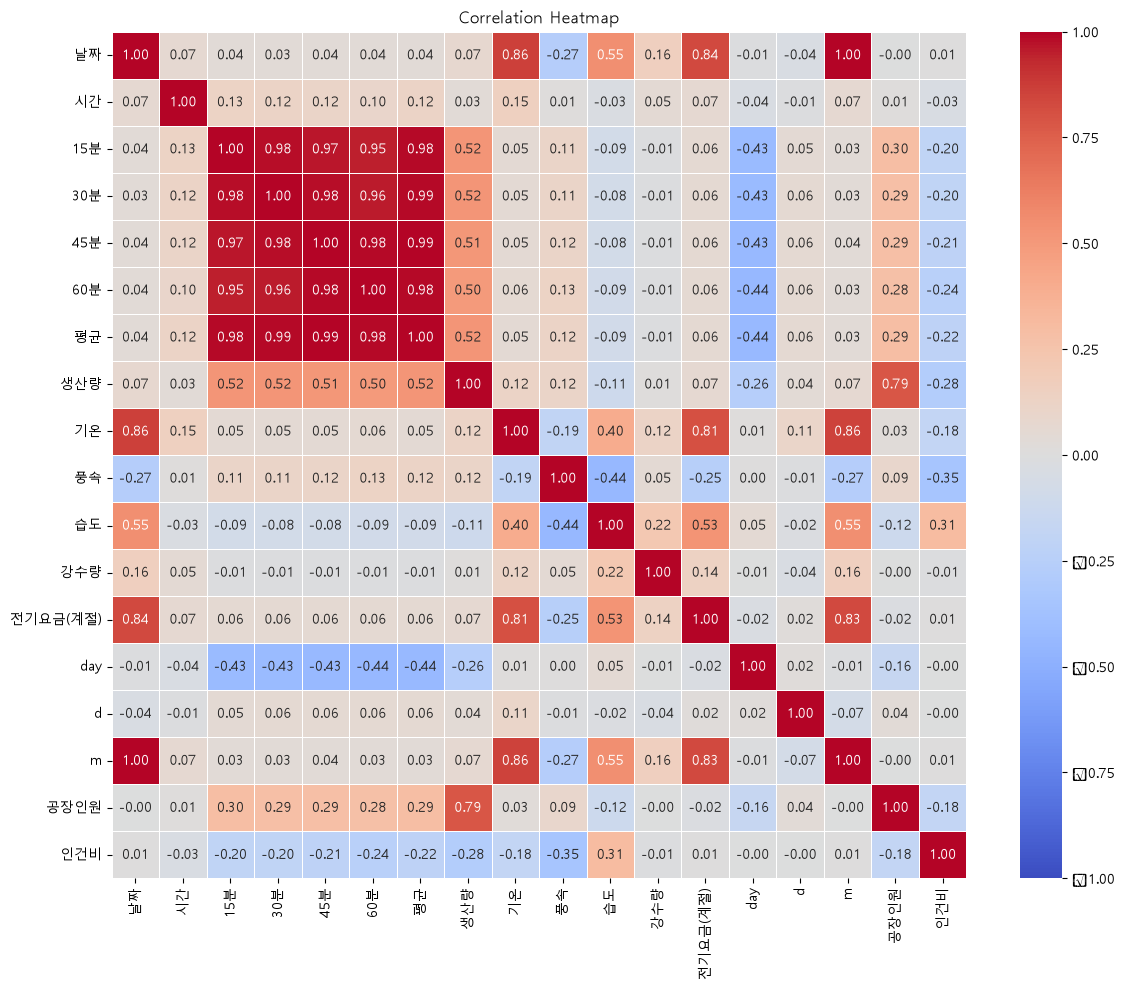

In [9]:
dataset_corr = dataset_interpolate.corr()

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(12, 10))

sns.heatmap(
    dataset_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,      
    fmt=".2f",      
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
dataset_drop = dataset_interpolate.iloc[:, :6]

dataset_drop.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   날짜      6168 non-null   int64
 1   시간      6168 non-null   int64
 2   15분     6168 non-null   int64
 3   30분     6168 non-null   int64
 4   45분     6168 non-null   int64
 5   60분     6168 non-null   int64
dtypes: int64(6)
memory usage: 289.3 KB


In [31]:
print(dataset_drop['날짜'].iloc[0], dataset_drop['날짜'].iloc[-1])

20210101 20210914


In [33]:
data_idx = pd.date_range(start='2021-01-01 00:00', end='2021-09-14 23:00', freq='h')

dataset_drop.index = data_idx
dataset_drop.index.names = ['Dates']

dataset_reindex = dataset_drop.drop(columns=['날짜', '시간'])
dataset_reindex.head()


,15분,30분,45분,60분
Dates,,,,
2021-01-01 00:00:00,62,61,61,61
2021-01-01 01:00:00,96,93,116,113
2021-01-01 02:00:00,106,96,106,107
2021-01-01 03:00:00,92,110,110,109
2021-01-01 04:00:00,108,105,106,108


In [35]:
dataset_float = dataset_reindex.astype(float)
dataset_float.head()

,15분,30분,45분,60분
Dates,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0


In [40]:
data_15min = []

for date, row in dataset_float.iterrows():

    for col, minutes in [
        ('15분', 15),
        ('30분', 30),
        ('45분', 45),
        ('60분', 60)
    ]:
        
        new_date = date + pd.Timedelta(minutes=minutes)
        
        data_15min.append([
            new_date,
            row[col],
        ])

data_15min = pd.DataFrame(
    data_15min,
    columns=['Date', '전력량']
)

data_15min = data_15min.set_index('Date')

data_15min.head()

,전력량
Date,
2021-01-01 00:15:00,62.0
2021-01-01 00:30:00,61.0
2021-01-01 00:45:00,61.0
2021-01-01 01:00:00,61.0
2021-01-01 01:15:00,96.0


In [46]:
data_15min['Weekend'] = (data_15min.index.dayofweek > 5).astype(float)

holidays = ['2021-01-01', '2021-02-11', '2021-02-12', '2021-03-01', '2021-05-05',
            '2021-05-19',' 2021-08-16']

data_15min['Vacation'] = (
    data_15min.index.normalize().isin(holidays)
).astype(float)

data_15min['minute_of_day'] = (
    data_15min.index.hour * 60
    + data_15min.index.minute
)

data_15min['time_sin'] = np.sin(
    2 * np.pi * data_15min['minute_of_day'] / (24 * 60)
)

data_15min['time_cos'] = np.cos(
    2 * np.pi * data_15min['minute_of_day'] / (24 * 60)
)

data_15min['day_of_week'] = data_15min.index.dayofweek.astype(float)

# 요일 주기
data_15min['day_sin'] = np.sin(
    2 * np.pi * data_15min['day_of_week'] / 7
)

data_15min['day_cos'] = np.cos(
    2 * np.pi * data_15min['day_of_week'] / 7
)

data_final = data_15min.drop(columns=['day_of_week', 'minute_of_day'])
data_final.head()

,전력량,Weekend,Vacation,time_sin,time_cos,DayOfWeek,day_sin,day_cos
Date,,,,,,,,
2021-01-01 00:15:00,62.0,0.0,0.0,0.065403,0.997859,4,-0.433884,-0.900969
2021-01-01 00:30:00,61.0,0.0,0.0,0.130526,0.991445,4,-0.433884,-0.900969
2021-01-01 00:45:00,61.0,0.0,0.0,0.195090,0.980785,4,-0.433884,-0.900969
2021-01-01 01:00:00,61.0,0.0,0.0,0.258819,0.965926,4,-0.433884,-0.900969
2021-01-01 01:15:00,96.0,0.0,0.0,0.321439,0.946930,4,-0.433884,-0.900969


In [74]:
output_path = os.path.join('dataset', 'data_final.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)

data_final.to_csv(
    output_path,
    index=True,
    encoding='utf-8-sig'
)

print(f'저장 완료: {output_path}')

저장 완료: dataset\data_final.csv
